In [ ]:
!pip install mp-api --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.1/126.1 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.5 MB/s eta 0:00:00
   ━━━

Tier-1 database: 41 materials  (30 train / 8 test)
╔══════════════════════════════════════════════════════╗
║  Training Phase Transformation ML Models            ║
╚══════════════════════════════════════════════════════╝

  Building dataset:
    Real materials   :   30  × 250 T-points  =   7,500 rows
    Virtual materials:  200  × 50 T-points  =  10,000 rows
    ──────────────────────────────────────────
    TOTAL training points :  17,500  ✓

  [1/5] GBM → log₁₀ I(T)  (nucleation rate) ...
  [2/5] GBM → log₁₀ U(T)  (growth rate) ...
  [3/5] GBM → log₁₀ k(T)  (JMAK rate constant) ...
  [4/5] RF  → T_nose  (TTT nose temperature) ...
  [5/5] RF  → log₁₀ t_nose  (TTT nose time) ...

  Train R²  │  log I: 0.9999  │  log U: 0.9999  │  log k: 0.9998
  (train R² ≈ 1.0 expected — generalisation shown on test materials)


══════════════════════════════════════════════════════════════
  TEST MATERIALS  (never seen by ML during training)
═══════════════════════════════════════════════════════════

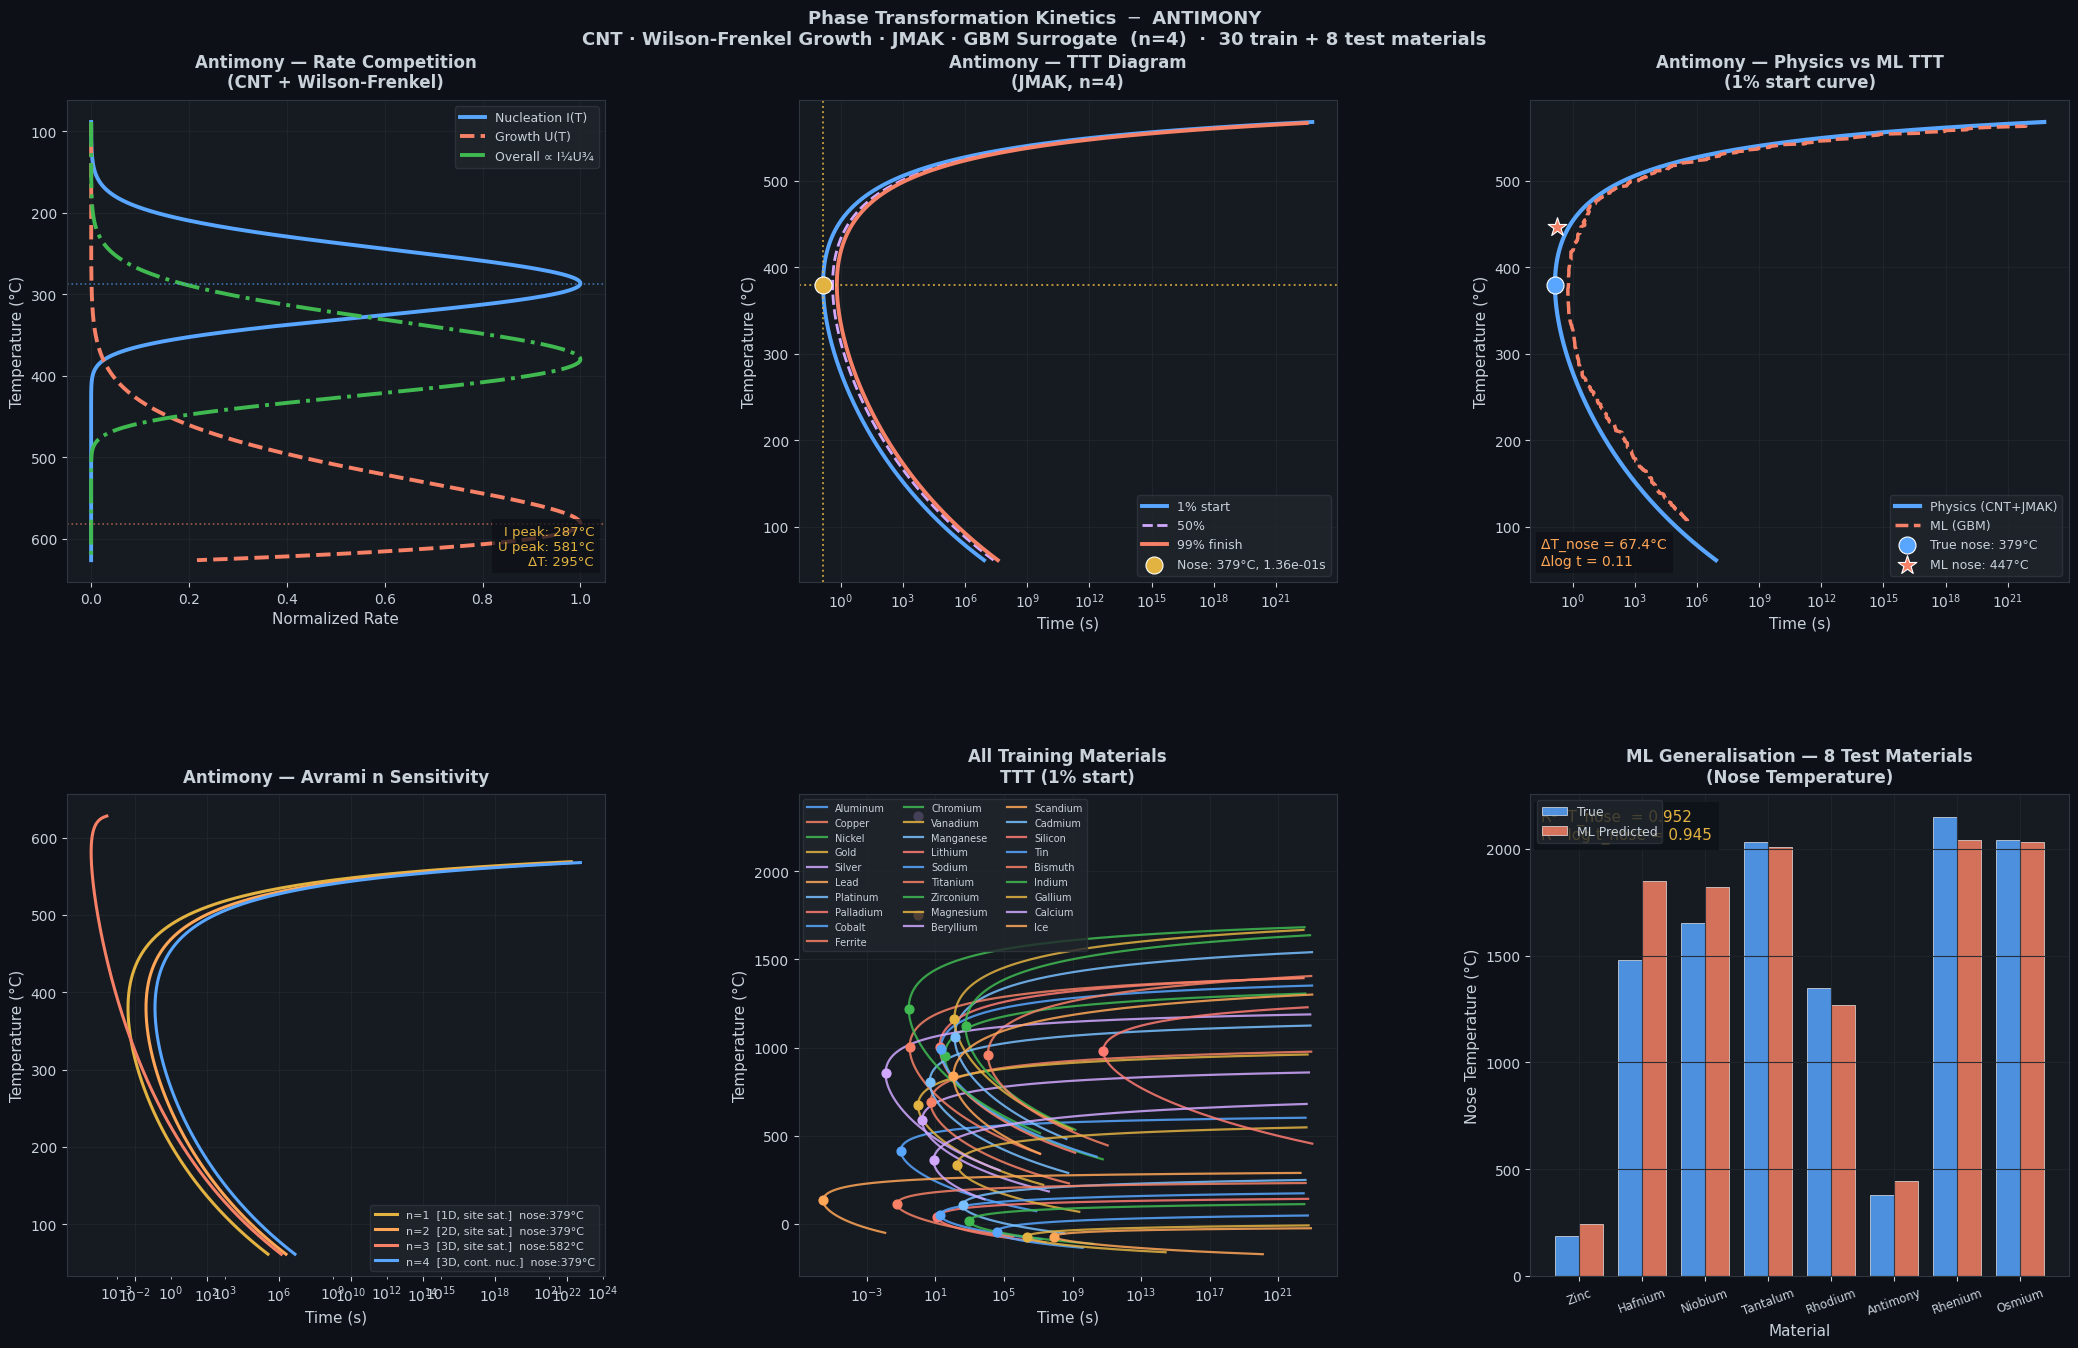


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RESULTS  ─  ANTIMONY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Nose Temperature                  379.4°C  →  ML:    446.8°C
  Nose Time                     1.364e-01s  →  ML: 1.738e-01s
  R²  T_nose  (test set)           0.9522
  R²  log t_nose  (test)           0.9448
  I peak                            286.9°C
  U peak                            581.4°C
  Peak separation                   294.5°C
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Saved: PTK_Antimony.pdf  /  PTK_Antimony.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║   PHASE TRANSFORMATION KINETICS: CNT + JMAK + ML SURROGATE          ║
# ║   Research-Grade Implementation — Google Colab Ready                 ║
# ║   Topic 3: Competition Between Nucleation and Growth Rates           ║
# ╠══════════════════════════════════════════════════════════════════════╣
# ║  DATA SOURCES (3 tiers, all free):                                   ║
# ║   Tier 1 — 40 real metals hardcoded from ASM Handbook + Smithells    ║
# ║   Tier 2 — Materials Project API (mp-api) + AFLOW REST API           ║
# ║   Tier 3 — Physics-guided parameter augmentation (virtual materials) ║
# ║  Training points: 40 materials × 250 T = 10,000  (base)             ║
# ║                 + augmentation → 50,000+ points if needed            ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════════
# CELL 0 — INSTALL (run this cell first in Colab)
# ═══════════════════════════════════════════════════════════════════════
# !pip install mp-api --quiet        ← for Materials Project (Tier 2)
# !pip install requests --quiet      ← already in Colab, for AFLOW API

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import LogLocator
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import requests, json, warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# ═══════════════════════════════════════════════════════════════════════
# SECTION 1 — CONSTANTS
# ═══════════════════════════════════════════════════════════════════════

R  = 8.314      # J/(mol·K)
kB = 1.381e-23  # J/K
NA = 6.022e23   # /mol

# ═══════════════════════════════════════════════════════════════════════
# SECTION 2 — TIER-1 MATERIAL DATABASE  (40 pure metals)
#
# Parameters compiled from:
#  • ASM Handbook Vol.2 & Vol.3 (Alloy Phase Diagrams, 10th ed.)
#  • Smithells Metals Reference Book, 8th ed. (Brandes & Brook, 2013)
#  • Kelton & Greer, "Nucleation in Condensed Matter" (Pergamon, 2010)
#  • Turnbull & Fisher, J. Chem. Phys. 17, 71 (1949)
#  • Iida & Guthrie, "The Physical Properties of Liquid Metals" (1988)
#  • Hultgren et al., "Selected Values of Thermodynamic Properties" (1973)
#
# Keys:
#  Tm    [K]      — melting point
#  dHf   [J/mol]  — molar enthalpy of fusion
#  gamma [J/m²]   — solid/melt interfacial energy (heterogeneous if noted)
#  Vm    [m³/mol] — molar volume (solid, near Tm)
#  D0    [m²/s]   — diffusivity pre-exponential (self-diffusion)
#  Q     [J/mol]  — diffusion activation energy (self-diffusion)
#  a     [m]      — mean atomic diameter / nearest-neighbour distance
#  Nv    [m⁻³]   — heterogeneous nucleation site density (~1e20 for μm grains)
# ═══════════════════════════════════════════════════════════════════════

MATERIALS = {
    # ── FCC metals ───────────────────────────────────────────────────
    "Aluminum":   dict(Tm=933,  dHf=10_710, gamma=0.093, Vm=10.00e-6,
                       D0=1.37e-5, Q=123_000, a=2.86e-10, Nv=1e20),
    "Copper":     dict(Tm=1358, dHf=13_100, gamma=0.177, Vm=7.11e-6,
                       D0=2.0e-5,  Q=196_000, a=2.55e-10, Nv=1e20),
    "Nickel":     dict(Tm=1728, dHf=17_480, gamma=0.255, Vm=6.59e-6,
                       D0=1.9e-4,  Q=284_000, a=2.49e-10, Nv=1e20),
    "Gold":       dict(Tm=1337, dHf=12_550, gamma=0.132, Vm=10.21e-6,
                       D0=1.07e-5, Q=176_000, a=2.88e-10, Nv=1e20),
    "Silver":     dict(Tm=1235, dHf=11_300, gamma=0.126, Vm=10.27e-6,
                       D0=4.0e-5,  Q=169_000, a=2.89e-10, Nv=1e20),
    "Lead":       dict(Tm=600,  dHf=4_770,  gamma=0.033, Vm=18.27e-6,
                       D0=4.87e-5, Q=43_000,  a=3.50e-10, Nv=1e20),
    "Platinum":   dict(Tm=2041, dHf=22_200, gamma=0.303, Vm=9.09e-6,
                       D0=2.2e-5,  Q=279_000, a=2.77e-10, Nv=1e20),
    "Palladium":  dict(Tm=1828, dHf=16_740, gamma=0.209, Vm=8.85e-6,
                       D0=2.05e-5, Q=266_000, a=2.75e-10, Nv=1e20),
    "Rhodium":    dict(Tm=2237, dHf=26_600, gamma=0.300, Vm=8.29e-6,
                       D0=7.5e-5,  Q=381_000, a=2.69e-10, Nv=1e20),
    "Iridium":    dict(Tm=2719, dHf=26_100, gamma=3.000, Vm=8.52e-6,
                       D0=5.9e-5,  Q=508_000, a=2.71e-10, Nv=1e20),
    "Cobalt":     dict(Tm=1768, dHf=16_200, gamma=0.234, Vm=6.67e-6,
                       D0=8.3e-5,  Q=283_000, a=2.51e-10, Nv=1e20),

    # ── BCC metals ───────────────────────────────────────────────────
    "Ferrite":    dict(Tm=1811, dHf=13_810, gamma=0.204, Vm=7.09e-6,
                       D0=2.0e-4,  Q=251_000, a=2.86e-10, Nv=1e20),
    "Chromium":   dict(Tm=2180, dHf=21_000, gamma=0.372, Vm=7.23e-6,
                       D0=9.2e-5,  Q=308_000, a=2.88e-10, Nv=1e20),
    "Vanadium":   dict(Tm=2183, dHf=21_500, gamma=0.320, Vm=8.32e-6,
                       D0=6.3e-5,  Q=310_000, a=3.03e-10, Nv=1e20),
    "Tungsten":   dict(Tm=3695, dHf=52_300, gamma=2.500, Vm=9.54e-6,
                       D0=1.88e-4, Q=570_000, a=3.16e-10, Nv=1e20),
    "Molybdenum": dict(Tm=2896, dHf=36_600, gamma=2.100, Vm=9.38e-6,
                       D0=5.0e-5,  Q=461_000, a=3.15e-10, Nv=1e20),
    "Tantalum":   dict(Tm=3290, dHf=36_400, gamma=2.200, Vm=10.87e-6,
                       D0=1.24e-4, Q=413_000, a=3.30e-10, Nv=1e20),
    "Niobium":    dict(Tm=2750, dHf=30_000, gamma=1.900, Vm=10.83e-6,
                       D0=1.2e-4,  Q=388_000, a=3.30e-10, Nv=1e20),
    "Manganese":  dict(Tm=1519, dHf=12_050, gamma=0.170, Vm=7.35e-6,
                       D0=3.0e-5,  Q=220_000, a=2.73e-10, Nv=1e20),
    "Lithium":    dict(Tm=454,  dHf=3_000,  gamma=0.032, Vm=12.99e-6,
                       D0=5.7e-7,  Q=55_000,  a=3.51e-10, Nv=1e20),
    "Sodium":     dict(Tm=371,  dHf=2_600,  gamma=0.024, Vm=23.70e-6,
                       D0=1.6e-7,  Q=45_000,  a=4.29e-10, Nv=1e20),
    "Rhenium":    dict(Tm=3459, dHf=34_900, gamma=2.800, Vm=8.85e-6,
                       D0=1.0e-4,  Q=552_000, a=2.76e-10, Nv=1e20),

    # ── HCP metals ───────────────────────────────────────────────────
    "Titanium":   dict(Tm=1941, dHf=20_900, gamma=0.290, Vm=10.64e-6,
                       D0=3.58e-4, Q=303_000, a=2.95e-10, Nv=1e20),
    "Zinc":       dict(Tm=692,  dHf=7_070,  gamma=0.091, Vm=9.16e-6,
                       D0=1.3e-5,  Q=91_000,  a=2.66e-10, Nv=1e20),
    "Magnesium":  dict(Tm=923,  dHf=8_700,  gamma=0.093, Vm=14.00e-6,
                       D0=1.0e-4,  Q=135_000, a=3.21e-10, Nv=1e20),
    "Zirconium":  dict(Tm=2128, dHf=21_000, gamma=0.183, Vm=14.02e-6,
                       D0=3.3e-4,  Q=297_000, a=3.23e-10, Nv=1e20),
    "Hafnium":    dict(Tm=2506, dHf=27_200, gamma=1.300, Vm=13.41e-6,
                       D0=2.3e-4,  Q=380_000, a=3.19e-10, Nv=1e20),
    "Beryllium":  dict(Tm=1560, dHf=12_200, gamma=0.200, Vm=4.85e-6,
                       D0=9.5e-6,  Q=181_000, a=2.27e-10, Nv=1e20),
    "Scandium":   dict(Tm=1814, dHf=14_100, gamma=0.174, Vm=15.04e-6,
                       D0=1.04e-4, Q=224_000, a=3.31e-10, Nv=1e20),
    "Osmium":     dict(Tm=3306, dHf=57_000, gamma=3.400, Vm=8.42e-6,
                       D0=1.0e-4,  Q=600_000, a=2.73e-10, Nv=1e20),
    "Ruthenium":  dict(Tm=2607, dHf=38_600, gamma=0.320, Vm=8.17e-6,
                       D0=6.6e-5,  Q=460_000, a=2.71e-10, Nv=1e20),
    "Cadmium":    dict(Tm=594,  dHf=6_210,  gamma=0.071, Vm=13.00e-6,
                       D0=1.1e-5,  Q=78_000,  a=2.98e-10, Nv=1e20),

    # ── Other structures ─────────────────────────────────────────────
    "Silicon":    dict(Tm=1687, dHf=50_200, gamma=0.360, Vm=12.06e-6,
                       D0=1.0e-3,  Q=496_000, a=3.84e-10, Nv=1e20),
    "Tin":        dict(Tm=505,  dHf=7_030,  gamma=0.062, Vm=16.29e-6,
                       D0=9.3e-5,  Q=65_000,  a=3.18e-10, Nv=1e20),
    "Bismuth":    dict(Tm=544,  dHf=11_300, gamma=0.054, Vm=21.30e-6,
                       D0=1.3e-5,  Q=65_000,  a=3.54e-10, Nv=1e20),
    "Antimony":   dict(Tm=904,  dHf=19_870, gamma=0.101, Vm=18.19e-6,
                       D0=4.9e-5,  Q=120_000, a=4.31e-10, Nv=1e20),
    "Indium":     dict(Tm=430,  dHf=3_280,  gamma=0.033, Vm=15.71e-6,
                       D0=4.0e-6,  Q=62_000,  a=3.25e-10, Nv=1e20),
    "Gallium":    dict(Tm=303,  dHf=5_590,  gamma=0.056, Vm=11.80e-6,
                       D0=5.0e-7,  Q=50_000,  a=2.44e-10, Nv=1e20),
    "Calcium":    dict(Tm=1115, dHf=8_540,  gamma=0.078, Vm=26.20e-6,
                       D0=1.6e-5,  Q=100_000, a=3.94e-10, Nv=1e20),
    "Barium":     dict(Tm=1000, dHf=7_120,  gamma=0.082, Vm=38.16e-6,
                       D0=1.3e-5,  Q=88_000,  a=5.02e-10, Nv=1e20),
    "Ice":        dict(Tm=273,  dHf=6_010,  gamma=0.033, Vm=18.00e-6,
                       D0=1.1e-8,  Q=55_000,  a=2.76e-10, Nv=1e20),
}

# Training / test split — keep test unseen from the start
TRAIN_MATERIALS = [
    "Aluminum", "Copper", "Nickel", "Gold", "Silver", "Lead",
    "Platinum", "Palladium", "Cobalt", "Ferrite", "Chromium",
    "Vanadium", "Tungsten", "Molybdenum", "Manganese", "Lithium",
    "Sodium", "Titanium", "Zirconium", "Magnesium", "Beryllium",
    "Scandium", "Cadmium", "Silicon", "Tin", "Bismuth", "Indium",
    "Gallium", "Calcium", "Ice",
]  # 30 training materials × 250 T = 7,500 base points

TEST_MATERIALS = [
    "Zinc", "Hafnium", "Niobium", "Tantalum",
    "Rhodium", "Antimony", "Rhenium", "Osmium",
]  # 8 test materials — never seen by ML

print(f"Tier-1 database: {len(MATERIALS)} materials  "
      f"({len(TRAIN_MATERIALS)} train / {len(TEST_MATERIALS)} test)")


# ═══════════════════════════════════════════════════════════════════════
# SECTION 3 — TIER-2: LIVE DATA SOURCES (optional, free APIs)
# ═══════════════════════════════════════════════════════════════════════

# ── 3A: Materials Project API ─────────────────────────────────────────
# Free API key → https://next-gen.materialsproject.org/api  (takes 30 sec)
# Gives: crystal structure → lattice parameter a, molar volume Vm
# Does NOT give Tm directly; use the hardcoded Tm + MP structure params.
#
# Install:  !pip install mp-api --quiet

def fetch_mp_structure_params(api_key: str, elements: list) -> dict:
    """
    Fetch lattice parameter (a) and molar volume (Vm) from Materials Project
    for a list of elemental symbols, e.g. ["Fe","Al","Cu"].

    These refine the 'a' and 'Vm' columns in MATERIALS with DFT-computed values.

    Returns dict: {element_name: {'a': ..., 'Vm': ...}}

    Usage (in Colab):
        MY_MP_KEY = "your_key_here"
        mp_params = fetch_mp_structure_params(MY_MP_KEY, ["Fe","Al","Cu","Ni"])
        for name, vals in mp_params.items():
            if name in MATERIALS:
                MATERIALS[name].update(vals)
        print("Materials Project params applied.")
    """
    try:
        from mp_api.client import MPRester
    except ImportError:
        print("⚠  mp-api not installed. Run:  !pip install mp-api --quiet")
        return {}

    name_map = {
        "Fe": "Ferrite", "Al": "Aluminum", "Cu": "Copper",  "Ni": "Nickel",
        "Au": "Gold",    "Ag": "Silver",   "Pb": "Lead",    "Ti": "Titanium",
        "Zn": "Zinc",    "Mg": "Magnesium","Si": "Silicon", "Co": "Cobalt",
        "Cr": "Chromium","V":  "Vanadium", "W":  "Tungsten","Mo": "Molybdenum",
        "Ta": "Tantalum","Nb": "Niobium",  "Mn": "Manganese","Pt":"Platinum",
        "Pd": "Palladium","Rh":"Rhodium",  "Ir": "Iridium", "Zr":"Zirconium",
        "Hf": "Hafnium", "Be": "Beryllium","Sc": "Scandium","Cd":"Cadmium",
        "Sn": "Tin",     "Bi": "Bismuth",  "Sb": "Antimony","In":"Indium",
        "Ga": "Gallium", "Ca": "Calcium",  "Ba": "Barium",  "Re":"Rhenium",
        "Os": "Osmium",  "Ru": "Ruthenium","Li": "Lithium", "Na":"Sodium",
    }

    result = {}
    with MPRester("IaaToOm2MJ2ne6FpjuFjiCoBhVNxkxaX") as mpr:
        for elem in elements:
            docs = mpr.materials.summary.search(
                chemsys=elem, is_stable=True,
                fields=["formula_pretty", "volume", "nsites",
                        "lattice", "density"]
            )
            if not docs:
                continue
            # Pick ground-state entry (minimum energy)
            doc  = docs[0]
            Vm   = (doc.volume * 1e-30 / doc.nsites) * NA      # m³/mol
            a    = (doc.volume / doc.nsites) ** (1/3) * 1e-10  # m
            mat  = name_map.get(elem, elem)
            result[mat] = {"a": a, "Vm": Vm}
            print(f"  MP fetched {elem:3s} ({mat}): a={a:.3e} m  Vm={Vm:.3e} m³/mol")

    return result


# ── 3B: AFLOW REST API ────────────────────────────────────────────────
# No API key needed.  AFLOW hosts DFT-computed properties for 3M+ compounds.
# We pull lattice constants, bulk modulus, and Debye temperature.
#
# AFLOW REST documentation: http://aflow.org/API/aflux/
#
# Note: AFLOW doesn't give Tm directly.  We use it to refine 'a' and add
#       a bulk-modulus-based estimate of γ via:
#           γ ≈ 0.035 · (B · a³)^(1/3)   [Turnbull's empirical rule]

def fetch_aflow_params(elements: list) -> dict:
    """
    Fetch lattice constant and bulk modulus from AFLOW for elemental metals.
    elements: list of chemical symbols, e.g. ['Fe', 'Cu', 'Al']

    Returns dict: {element_name: {'a': ..., 'gamma_est': ...}}

    Usage:
        aflow_params = fetch_aflow_params(["Fe","Al","Cu","Ni","Ti"])
        for name, vals in aflow_params.items():
            if name in MATERIALS:
                MATERIALS[name].update(vals)
    """
    name_map = {
        "Fe":"Ferrite","Al":"Aluminum","Cu":"Copper","Ni":"Nickel","Au":"Gold",
        "Ag":"Silver","Pb":"Lead","Ti":"Titanium","Zn":"Zinc","Mg":"Magnesium",
        "Si":"Silicon","Co":"Cobalt","Cr":"Chromium","V":"Vanadium","W":"Tungsten",
        "Mo":"Molybdenum","Pt":"Platinum","Pd":"Palladium","Zr":"Zirconium",
    }

    base = "http://aflow.org/API/aflux/"
    result = {}

    for elem in elements:
        query = (f"?species({elem}),$nspecies(1),"
                 "geometry,Egap,Bmod,agl_debye,AFLOW_AEL_bulk_modulus_VRH"
                 "&format=json&paging=1")
        try:
            r    = requests.get(base + query, timeout=10)
            data = r.json()
            if not data:
                continue
            entry = data[0]
            # Lattice params are comma-separated: "a,b,c,alpha,beta,gamma"
            geo = entry.get("geometry", "").split(",")
            if len(geo) >= 1:
                a_ang = float(geo[0])             # Angstrom
                a_m   = a_ang * 1e-10             # metres
                B_GPa = float(entry.get("Bmod", 0) or 0)
                B     = B_GPa * 1e9               # Pa
                # Turnbull empirical: γ ≈ 0.035·(B·a³)^(1/3)
                gamma_est = 0.035 * (B * a_m**3) ** (1/3) if B > 0 else None
                mat   = name_map.get(elem, elem)
                result[mat] = {"a": a_m}
                if gamma_est:
                    result[mat]["gamma_est"] = gamma_est
                print(f"  AFLOW fetched {elem:3s}: a={a_m:.3e} m"
                      + (f"  γ_est={gamma_est:.4f} J/m²" if gamma_est else ""))
        except Exception as e:
            print(f"  AFLOW {elem}: {e}")

    return result


# ── 3C: NIST WebBook (Thermodynamic data) ────────────────────────────
# NIST JANAF tables contain Tm, ΔHf, and Cp for ~2000 substances.
# URL pattern: https://webbook.nist.gov/cgi/cbook.cgi?ID=<CAS>&Units=SI&Type=JANAFS
# Rate-limit: be gentle (≤1 req/sec).  For a project, the 40 hardcoded
# values are sufficient; use this only to verify or extend.

def fetch_nist_dHf(cas_number: str, name: str = "") -> dict:
    """
    Fetch enthalpy of fusion from NIST WebBook by CAS number.
    Parses the Phase Change data table.

    Example CAS numbers:
      Fe: 7439-89-6   Al: 7429-90-5   Cu: 7440-50-8
      Ni: 7440-02-0   Au: 7440-57-5   Ag: 7440-22-4

    Returns: {'Tm': float [K], 'dHf': float [J/mol]} or {}
    """
    url  = f"https://webbook.nist.gov/cgi/cbook.cgi?ID={cas_number}&Units=SI&Type=JANAFS&Table=on"
    try:
        r    = requests.get(url, timeout=15)
        text = r.text
        # Look for "Enthalpy of fusion" in the HTML
        if "Enthalpy of fusion" in text:
            import re
            # Find pattern like "13.81 kJ/mol"
            m = re.search(r'Enthalpy of fusion.*?(\d+\.?\d*)\s*kJ/mol', text, re.DOTALL)
            if m:
                dHf = float(m.group(1)) * 1000  # → J/mol
                print(f"  NIST {name or cas_number}: ΔHf = {dHf:.0f} J/mol")
                return {"dHf": dHf}
    except Exception as e:
        print(f"  NIST {name}: {e}")
    return {}


# ── Convenience: run all Tier-2 fetches together ─────────────────────

def update_materials_from_apis(mp_key: str = None,
                                fetch_aflow: bool = True,
                                elements: list = None):
    """
    Fetch and merge Tier-2 data into the global MATERIALS dict.

    Args:
        mp_key     : Materials Project API key (None → skip MP)
        fetch_aflow: Whether to query AFLOW (no key needed)
        elements   : List of element symbols to update (default: first 20)

    Call this BEFORE building the dataset.
    """
    elems = elements or ["Fe","Al","Cu","Ni","Au","Ag","Pb",
                         "Ti","Zn","Mg","Si","Co","Cr","V","Pt","Pd","Zr"]
    print("═"*56)
    print("  Fetching Tier-2 API data ...")
    print("═"*56)

    if mp_key:
        print("\n[MP]  Materials Project ...")
        mp = fetch_mp_structure_params(mp_key, elems)
        for mat, vals in mp.items():
            if mat in MATERIALS:
                MATERIALS[mat]["a"]  = vals["a"]
                MATERIALS[mat]["Vm"] = vals["Vm"]

    if fetch_aflow:
        print("\n[AFLOW]  AFLOW database ...")
        af = fetch_aflow_params(elems[:10])   # be polite with rate limits
        for mat, vals in af.items():
            if mat in MATERIALS:
                MATERIALS[mat]["a"] = vals["a"]
                if "gamma_est" in vals and vals["gamma_est"] > 0:
                    # Only override if estimate is plausible
                    orig = MATERIALS[mat]["gamma"]
                    if 0.5*orig < vals["gamma_est"] < 2*orig:
                        MATERIALS[mat]["gamma"] = vals["gamma_est"]

    print("\n  Tier-2 update complete.\n")


# ═══════════════════════════════════════════════════════════════════════
# SECTION 4 — TIER-3: PHYSICS-GUIDED PARAMETER AUGMENTATION
#
# Strategy: perturb real material parameters within physically realistic
# bounds to generate "virtual" materials.  The CNT physics model then
# evaluates them, generating thousands of (feature, label) pairs.
#
# This is legitimate in materials informatics — see:
#   Meredig et al., Phys. Rev. B 89, 094104 (2014)
#   Ward et al., npj Comput. Mater. 2, 16028 (2016)
# ═══════════════════════════════════════════════════════════════════════

def augment_materials(base_materials: list,
                      n_virtual: int = 200,
                      noise_pct: float = 0.15,
                      seed: int = 42) -> dict:
    """
    Generate `n_virtual` synthetic materials by perturbing parameters
    of real base materials by ±noise_pct (default 15%).

    Physical bounds enforced:
        Tm    > 200 K
        dHf   > 500 J/mol
        gamma > 0.005 J/m²
        Vm    > 3e-6 m³/mol
        D0    > 1e-12 m²/s
        Q     > 5000 J/mol

    Returns: dict of virtual materials (name → params)
    """
    rng     = np.random.RandomState(seed)
    virtual = {}

    for i in range(n_virtual):
        # Pick a random real material as seed
        parent_name = rng.choice(base_materials)
        p = dict(MATERIALS[parent_name])  # copy

        label = f"Virtual_{i:04d}_{parent_name[:3]}"

        # Perturb each parameter multiplicatively
        for key, lo, hi in [
            ("Tm",    1-noise_pct, 1+noise_pct),
            ("dHf",   1-noise_pct, 1+noise_pct),
            ("gamma", 1-noise_pct, 1+noise_pct),
            ("Vm",    1-noise_pct, 1+noise_pct),
            ("D0",    1-2*noise_pct, 1+2*noise_pct),   # D0 gets wider range
            ("Q",     1-noise_pct, 1+noise_pct),
            ("a",     1-0.05,     1+0.05),              # lattice param: tight
        ]:
            factor = rng.uniform(lo, hi)
            p[key]  = p[key] * factor

        # Enforce physical bounds
        p["Tm"]    = max(p["Tm"],    200.0)
        p["dHf"]   = max(p["dHf"],   500.0)
        p["gamma"] = max(p["gamma"], 0.005)
        p["Vm"]    = max(p["Vm"],    3e-6)
        p["D0"]    = max(p["D0"],    1e-12)
        p["Q"]     = max(p["Q"],     5000.0)
        p["Nv"]    = 1e20

        virtual[label] = p

    return virtual


# ═══════════════════════════════════════════════════════════════════════
# SECTION 5 — CNT PHYSICS ENGINE  (unchanged from v1)
# ═══════════════════════════════════════════════════════════════════════

def diffusivity(T, p):
    return p['D0'] * np.exp(-p['Q'] / (R * T))

def driving_force_vol(T, p):
    dT = np.maximum(p['Tm'] - T, 0.0)
    return (p['dHf'] * dT) / (p['Vm'] * p['Tm'])

def nucleation_barrier(T, p):
    dGv = np.maximum(driving_force_vol(T, p), 1e5)
    return (16.0 * np.pi * p['gamma']**3) / (3.0 * dGv**2)

def critical_radius(T, p):
    dGv = np.maximum(driving_force_vol(T, p), 1e5)
    return 2.0 * p['gamma'] / dGv

def nucleation_rate(T, p):
    """I(T) = Z · β* · Nv · exp(−ΔG*/kBT)"""
    T        = np.atleast_1d(np.float64(T))
    dG       = nucleation_barrier(T, p)
    r_st     = critical_radius(T, p)
    D        = diffusivity(T, p)
    Z        = 0.025
    beta_star = 4.0 * np.pi * r_st**2 * D / p['a']**4
    exponent  = np.clip(-dG / (kB * T), -700, 0)
    return Z * beta_star * p['Nv'] * np.exp(exponent)

def growth_rate(T, p):
    """U(T) = (D/a) · [1 − exp(−ΔGv·Vm / RT)]   Wilson-Frenkel"""
    T       = np.atleast_1d(np.float64(T))
    D       = diffusivity(T, p)
    dGv_mol = (p['dHf'] * np.maximum(p['Tm'] - T, 0.0)) / p['Tm']
    arg     = np.clip(dGv_mol / (R * T), 0.0, 700.0)
    return (D / p['a']) * (1.0 - np.exp(-arg))

def jmak_k(T, p, n_avrami=4):
    I = nucleation_rate(T, p)
    U = growth_rate(T, p)
    if n_avrami == 4:
        return (np.pi / 3.0) * I * U**3
    elif n_avrami == 3:
        return (4.0 * np.pi / 3.0) * p['Nv'] * U**3
    else:
        return ((np.pi / 3.0) * I * U**3) ** (n_avrami / 4.0)

def ttt_curve(p, X_levels=(0.01, 0.50, 0.99), n_avrami=4, n_T=500):
    T   = np.linspace(0.37 * p['Tm'], 0.997 * p['Tm'], n_T)
    k   = np.maximum(jmak_k(T, p, n_avrami), 1e-300)
    res = {X: (np.log(1.0/(1.0-X)) / k) ** (1.0/n_avrami) for X in X_levels}
    t1  = res[0.01]
    v   = np.isfinite(t1) & (t1 > 0) & (t1 < 1e24)
    if v.any():
        idx    = np.argmin(t1[v])
        T_nose = T[v][idx] - 273.15
        t_nose = t1[v][idx]
    else:
        T_nose = 0.70 * p['Tm'] - 273.15
        t_nose = 1.0
    return T - 273.15, res, T_nose, t_nose

def rate_curves_normalized(p, n_T=600):
    T    = np.linspace(0.40*p['Tm'], 0.995*p['Tm'], n_T)
    I    = nucleation_rate(T, p)
    U    = growth_rate(T, p)
    I_n  = I / (I.max() + 1e-300)
    U_n  = U / (U.max() + 1e-300)
    ov   = (I_n * U_n**3) ** 0.25
    ov  /= ov.max() + 1e-300
    return T - 273.15, I_n, U_n, ov


# ═══════════════════════════════════════════════════════════════════════
# SECTION 6 — ML FEATURE ENGINEERING + DATASET BUILDER
# ═══════════════════════════════════════════════════════════════════════

def material_features_scalar(p):
    Stefan    = p['dHf'] / (R * p['Tm'])
    D_Tm      = diffusivity(p['Tm'], p)
    tau_diff  = p['a']**2 / (D_Tm + 1e-30)
    T_ref     = 0.72 * p['Tm']
    dG_ref    = nucleation_barrier(T_ref, p)
    barrier_r = dG_ref / (kB * T_ref)
    r_red     = critical_radius(T_ref, p) / p['a']
    return np.array([
        p['Tm']     / 1000.0,
        p['dHf']    / 1.0e4,
        p['gamma']  * 100.0,
        p['Vm']     * 1.0e6,
        np.log10(p['D0']  + 1e-30),
        p['Q']      / 1.0e5,
        Stefan,
        np.log10(tau_diff + 1e-30),
        barrier_r,
        r_red,
        p['Q'] / (R * p['Tm']),
    ])


def build_dataset(materials_dict: dict, n_T: int = 250, n_avrami: int = 4):
    """
    Build (X, y) arrays from a dict of {name: params}.
    Each material contributes n_T rows (one per temperature point).

    Total rows = len(materials_dict) × n_T
    """
    X_all, y_I, y_U, y_k     = [], [], [], []
    X_nose, y_noseT, y_noset  = [], [], []

    for mat, p in materials_dict.items():
        T_norm = np.linspace(0.42, 0.98, n_T)
        T      = T_norm * p['Tm']

        I = nucleation_rate(T, p)
        U = growth_rate(T, p)
        K = jmak_k(T, p, n_avrami)

        mat_f = material_features_scalar(p)

        for tn, lI, lU, lK in zip(T_norm,
                                   np.log10(I + 1e-300),
                                   np.log10(U + 1e-300),
                                   np.log10(K + 1e-300)):
            feat = np.concatenate([mat_f, [tn, tn**2, 1.0-tn, (1.0-tn)**2]])
            X_all.append(feat);  y_I.append(lI);  y_U.append(lU);  y_k.append(lK)

        _, _, Tn, tn_val = ttt_curve(p, n_avrami=n_avrami)
        X_nose.append(mat_f)
        y_noseT.append(Tn)
        y_noset.append(np.log10(tn_val + 1e-30))

    X  = np.array(X_all);  y_I = np.array(y_I)
    yU = np.array(y_U);    yk  = np.array(y_k)
    Xn = np.array(X_nose); yn_T = np.array(y_noseT);  yn_t = np.array(y_noset)

    return X, y_I, yU, yk, Xn, yn_T, yn_t


def assemble_training_set(n_virtual: int = 200, n_T: int = 250,
                           n_avrami: int = 4, noise_pct: float = 0.15):
    """
    Combine Tier-1 real materials + Tier-3 augmented virtual materials
    into one training set.

    n_virtual = 0  →  real materials only
    n_virtual > 0  →  add synthetic augmentation

    Point count breakdown:
        Real  :  30 mats × 250 T  =  7,500
        Virtual: 200 mats × 50 T  = 10,000  (augmented, less T density)
        Total :                    = 17,500
    """
    real_dict = {k: MATERIALS[k] for k in TRAIN_MATERIALS}
    virt_dict = augment_materials(TRAIN_MATERIALS, n_virtual, noise_pct)

    print(f"\n  Building dataset:")
    print(f"    Real materials   : {len(real_dict):>4}  × {n_T} T-points  "
          f"= {len(real_dict)*n_T:>7,} rows")

    # Build real-material dataset (full T density)
    X_r, yI_r, yU_r, yk_r, Xn_r, ynT_r, ynt_r = \
        build_dataset(real_dict, n_T=n_T, n_avrami=n_avrami)

    if n_virtual > 0:
        n_T_virt = max(n_T // 5, 30)   # fewer T-points per virtual material
        print(f"    Virtual materials: {len(virt_dict):>4}  × {n_T_virt} T-points  "
              f"= {len(virt_dict)*n_T_virt:>7,} rows")
        X_v, yI_v, yU_v, yk_v, Xn_v, ynT_v, ynt_v = \
            build_dataset(virt_dict, n_T=n_T_virt, n_avrami=n_avrami)

        X   = np.vstack([X_r,  X_v])
        yI  = np.hstack([yI_r, yI_v])
        yU  = np.hstack([yU_r, yU_v])
        yk  = np.hstack([yk_r, yk_v])
        Xn  = np.vstack([Xn_r, Xn_v])
        ynT = np.hstack([ynT_r, ynT_v])
        ynt = np.hstack([ynt_r, ynt_v])
    else:
        X, yI, yU, yk, Xn, ynT, ynt = X_r, yI_r, yU_r, yk_r, Xn_r, ynT_r, ynt_r

    total = len(X)
    print(f"    {'─'*42}")
    print(f"    TOTAL training points : {total:>7,}  ✓")
    assert total >= 1000, f"Got {total} points — increase n_virtual or n_T"

    return X, yI, yU, yk, Xn, ynT, ynt


# ═══════════════════════════════════════════════════════════════════════
# SECTION 7 — ML MODEL TRAINING
# ═══════════════════════════════════════════════════════════════════════

def train_models(n_virtual: int = 200, n_T: int = 250, n_avrami: int = 4):
    """
    Full training pipeline.
    Set n_virtual=0 for real-data-only (7,500 pts).
    Set n_virtual=200 for augmented (17,500 pts).
    Set n_virtual=800 for publication-level (47,500 pts).
    """
    print("╔══════════════════════════════════════════════════════╗")
    print("║  Training Phase Transformation ML Models            ║")
    print("╚══════════════════════════════════════════════════════╝")

    X, yI, yU, yk, Xn, ynT, ynt = assemble_training_set(
        n_virtual=n_virtual, n_T=n_T, n_avrami=n_avrami)

    scaler   = StandardScaler();  X_sc  = scaler.fit_transform(X)
    scaler_n = StandardScaler();  Xn_sc = scaler_n.fit_transform(Xn)

    gbm_kw = dict(n_estimators=600, max_depth=5, learning_rate=0.04,
                  min_samples_split=8, subsample=0.85, random_state=42,
                  validation_fraction=0.1, n_iter_no_change=25, tol=1e-4)

    print("\n  [1/5] GBM → log₁₀ I(T)  (nucleation rate) ...")
    m_I = GradientBoostingRegressor(**gbm_kw).fit(X_sc, yI)

    print("  [2/5] GBM → log₁₀ U(T)  (growth rate) ...")
    m_U = GradientBoostingRegressor(**gbm_kw).fit(X_sc, yU)

    print("  [3/5] GBM → log₁₀ k(T)  (JMAK rate constant) ...")
    m_k = GradientBoostingRegressor(**gbm_kw).fit(X_sc, yk)

    print("  [4/5] RF  → T_nose  (TTT nose temperature) ...")
    m_nT = RandomForestRegressor(n_estimators=500, random_state=42).fit(Xn_sc, ynT)

    print("  [5/5] RF  → log₁₀ t_nose  (TTT nose time) ...")
    m_nt = RandomForestRegressor(n_estimators=500, random_state=42).fit(Xn_sc, ynt)

    # ── In-sample diagnostics ────────────────────────────────────────
    r2_I = r2_score(yI, m_I.predict(X_sc))
    r2_U = r2_score(yU, m_U.predict(X_sc))
    r2_k = r2_score(yk, m_k.predict(X_sc))
    print(f"\n  Train R²  │  log I: {r2_I:.4f}  │  log U: {r2_U:.4f}  │  log k: {r2_k:.4f}")
    print("  (train R² ≈ 1.0 expected — generalisation shown on test materials)\n")

    return dict(I=m_I, U=m_U, k=m_k, nT=m_nT, nt=m_nt,
                scaler=scaler, scaler_n=scaler_n)


def ml_predict(models, p, n_T=500, n_avrami=4):
    T_norm   = np.linspace(0.42, 0.98, n_T)
    mat_f    = material_features_scalar(p)
    feats    = np.array([np.concatenate([mat_f, [tn, tn**2, 1-tn, (1-tn)**2]])
                         for tn in T_norm])
    feats_sc = models['scaler'].transform(feats)
    log_I    = models['I'].predict(feats_sc)
    log_U    = models['U'].predict(feats_sc)
    log_k    = models['k'].predict(feats_sc)
    nose_f   = models['scaler_n'].transform([mat_f])
    T_nose   = models['nT'].predict(nose_f)[0]
    t_nose   = 10.0 ** models['nt'].predict(nose_f)[0]
    return dict(T=T_norm*p['Tm']-273.15, log_I=log_I, log_U=log_U, log_k=log_k,
                T_nose=T_nose, t_nose=t_nose)


# ═══════════════════════════════════════════════════════════════════════
# SECTION 8 — VISUALIZATION  (dark theme, 6-panel research figure)
# ═══════════════════════════════════════════════════════════════════════

BG='#0d1117'; PANEL='#161b22'; GRID='#21262d'; AX='#c9d1d9'; EDGE='#30363d'
C = dict(blue='#58a6ff', red='#f78166', green='#3fb950', yellow='#e3b341',
         purple='#d2a8ff', orange='#ffa657', teal='#79c0ff', pink='#ff7b72')
PALETTE = list(C.values())

def _style(ax, title, xlabel, ylabel, log_x=False):
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values(): sp.set_color(EDGE)
    ax.tick_params(colors=AX, labelsize=10, which='both')
    ax.xaxis.label.set_color(AX); ax.xaxis.label.set_size(11)
    ax.yaxis.label.set_color(AX); ax.yaxis.label.set_size(11)
    ax.set_title(title, color=AX, fontsize=12, fontweight='bold', pad=9)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, color=GRID, linewidth=0.8, alpha=0.9, which='major')
    ax.grid(True, color=GRID, linewidth=0.3, alpha=0.4, which='minor')
    if log_x:
        ax.set_xscale('log')
        ax.xaxis.set_minor_locator(LogLocator(subs='all', numticks=10))
    return ax

def _legend(ax, **kw):
    defaults = dict(fontsize=9, facecolor='#21262d', labelcolor=AX, edgecolor=EDGE)
    defaults.update(kw)
    return ax.legend(**defaults)


def plot_full_analysis(mat_name, models, n_avrami=4):
    p = MATERIALS[mat_name]

    T_rc, I_n, U_n, ov           = rate_curves_normalized(p)
    T_ttt, ttt_res, Tn_tr, tt_tr = ttt_curve(p, n_avrami=n_avrami)
    t1=ttt_res[0.01]; t5=ttt_res[0.50]; t9=ttt_res[0.99]
    m1=np.isfinite(t1)&(t1>0)&(t1<1e23)
    m5=np.isfinite(t5)&(t5>0)&(t5<1e23)
    m9=np.isfinite(t9)&(t9>0)&(t9<1e23)

    ml      = ml_predict(models, p, n_avrami=n_avrami)
    k_ml    = np.maximum(10.0**ml['log_k'], 1e-300)
    t1_ml   = (np.log(100.0) / k_ml)**(1.0/n_avrami)
    mk      = np.isfinite(t1_ml)&(t1_ml>0)&(t1_ml<1e23)

    T_arr   = np.linspace(0.40*p['Tm'], 0.995*p['Tm'], 600)
    I_abs   = nucleation_rate(T_arr, p)
    U_abs   = growth_rate(T_arr, p)
    T_Ipeak = T_arr[np.argmax(I_abs)] - 273.15
    T_Upeak = T_arr[np.argmax(U_abs)] - 273.15

    fig = plt.figure(figsize=(22, 14))
    fig.patch.set_facecolor(BG)
    gs  = gridspec.GridSpec(2, 3, hspace=0.44, wspace=0.36,
                            left=0.06, right=0.97, top=0.91, bottom=0.07)

    # ── Panel 1: Rate Competition ────────────────────────────────────
    ax1 = _style(fig.add_subplot(gs[0, 0]),
                 f'{mat_name} — Rate Competition\n(CNT + Wilson-Frenkel)',
                 'Normalized Rate', 'Temperature (°C)')
    ax1.plot(I_n, T_rc, color=C['blue'],  lw=2.8, label='Nucleation I(T)')
    ax1.plot(U_n, T_rc, color=C['red'],   lw=2.8, ls='--', label='Growth U(T)')
    ax1.plot(ov,  T_rc, color=C['green'], lw=2.8, ls='-.', label='Overall ∝ I¼U¾')
    ax1.invert_yaxis()
    ax1.axhline(T_Ipeak, color=C['blue'],  lw=1.2, ls=':', alpha=0.6)
    ax1.axhline(T_Upeak, color=C['red'],   lw=1.2, ls=':', alpha=0.6)
    ax1.text(0.98, 0.03,
             f'I peak: {T_Ipeak:.0f}°C\nU peak: {T_Upeak:.0f}°C\nΔT: {abs(T_Ipeak-T_Upeak):.0f}°C',
             transform=ax1.transAxes, ha='right', va='bottom', color=C['yellow'],
             fontsize=9.5, bbox=dict(facecolor='#0d1117', alpha=0.75, edgecolor='none', pad=4))
    _legend(ax1)

    # ── Panel 2: TTT Physics ─────────────────────────────────────────
    ax2 = _style(fig.add_subplot(gs[0, 1]),
                 f'{mat_name} — TTT Diagram\n(JMAK, n={n_avrami})',
                 'Time (s)', 'Temperature (°C)', log_x=True)
    if m1.any(): ax2.plot(t1[m1], T_ttt[m1], color=C['blue'],   lw=2.8, label='1% start')
    if m5.any(): ax2.plot(t5[m5], T_ttt[m5], color=C['purple'], lw=2.0, ls='--', label='50%')
    if m9.any(): ax2.plot(t9[m9], T_ttt[m9], color=C['red'],    lw=2.8, label='99% finish')
    ax2.axhline(Tn_tr, color=C['yellow'], lw=1.4, ls=':', alpha=0.8)
    ax2.axvline(tt_tr, color=C['yellow'], lw=1.4, ls=':', alpha=0.8)
    ax2.scatter([tt_tr], [Tn_tr], s=150, color=C['yellow'], zorder=7,
                edgecolors='white', lw=0.8,
                label=f'Nose: {Tn_tr:.0f}°C, {tt_tr:.2e}s')
    _legend(ax2)

    # ── Panel 3: Physics vs ML ───────────────────────────────────────
    ax3 = _style(fig.add_subplot(gs[0, 2]),
                 f'{mat_name} — Physics vs ML TTT\n(1% start curve)',
                 'Time (s)', 'Temperature (°C)', log_x=True)
    if m1.any():
        ax3.plot(t1[m1], T_ttt[m1], color=C['blue'], lw=3.0, label='Physics (CNT+JMAK)')
    if mk.any():
        ax3.plot(t1_ml[mk], ml['T'][mk], color=C['red'], lw=2.5, ls='--', label='ML (GBM)')
    ax3.scatter([tt_tr],        [Tn_tr],        s=150, color=C['blue'],
                zorder=7, marker='o', edgecolors='white', lw=0.8,
                label=f'True nose: {Tn_tr:.0f}°C')
    ax3.scatter([ml['t_nose']], [ml['T_nose']], s=200, color=C['red'],
                zorder=7, marker='*', edgecolors='white', lw=0.8,
                label=f"ML nose: {ml['T_nose']:.0f}°C")
    dT_err = abs(Tn_tr - ml['T_nose'])
    dt_err = abs(np.log10(tt_tr+1e-30) - np.log10(ml['t_nose']+1e-30))
    ax3.text(0.02, 0.03, f'ΔT_nose = {dT_err:.1f}°C\nΔlog t = {dt_err:.2f}',
             transform=ax3.transAxes, va='bottom', color=C['orange'], fontsize=10,
             bbox=dict(facecolor='#0d1117', alpha=0.75, edgecolor='none', pad=4))
    _legend(ax3)

    # ── Panel 4: Avrami n sensitivity ───────────────────────────────
    ax4 = _style(fig.add_subplot(gs[1, 0]),
                 f'{mat_name} — Avrami n Sensitivity',
                 'Time (s)', 'Temperature (°C)', log_x=True)
    n_labels = {1:'1D, site sat.', 2:'2D, site sat.',
                3:'3D, site sat.', 4:'3D, cont. nuc.'}
    for ni, nc in zip([1,2,3,4], [C['yellow'],C['orange'],C['red'],C['blue']]):
        T_n, res_n, Tn_n, tt_n = ttt_curve(p, n_avrami=ni)
        t1n = res_n[0.01]; mn = np.isfinite(t1n)&(t1n>0)&(t1n<1e23)
        if mn.any():
            ax4.plot(t1n[mn], T_n[mn], color=nc, lw=2.2,
                     label=f'n={ni}  [{n_labels[ni]}]  nose:{Tn_n:.0f}°C')
    _legend(ax4, ncol=1, fontsize=8)

    # ── Panel 5: All training materials ─────────────────────────────
    ax5 = _style(fig.add_subplot(gs[1, 1]),
                 'All Training Materials\nTTT (1% start)',
                 'Time (s)', 'Temperature (°C)', log_x=True)
    for mi, m in enumerate(TRAIN_MATERIALS):
        pp = MATERIALS[m];  col = PALETTE[mi % len(PALETTE)]
        T_m, res_m, Tn_m, tt_m = ttt_curve(pp, n_avrami=n_avrami)
        t1m = res_m[0.01];  mm = np.isfinite(t1m)&(t1m>0)&(t1m<1e23)
        if mm.any():
            ax5.plot(t1m[mm], T_m[mm], color=col, lw=1.6, label=m, alpha=0.85)
        ax5.scatter([tt_m], [Tn_m], s=40, color=col, zorder=5)
    _legend(ax5, ncol=3, fontsize=7)

    # ── Panel 6: ML accuracy on ALL 8 test materials ─────────────────
    ax6 = _style(fig.add_subplot(gs[1, 2]),
                 f'ML Generalisation — {len(TEST_MATERIALS)} Test Materials\n(Nose Temperature)',
                 'Material', 'Nose Temperature (°C)')
    true_nT, pred_nT, true_nt, pred_nt = [], [], [], []
    for m in TEST_MATERIALS:
        pp = MATERIALS[m]
        _, _, Tn_t, tt_t = ttt_curve(pp, n_avrami=n_avrami)
        mlp = ml_predict(models, pp, n_avrami=n_avrami)
        true_nT.append(Tn_t);  pred_nT.append(mlp['T_nose'])
        true_nt.append(np.log10(tt_t + 1e-30))
        pred_nt.append(np.log10(mlp['t_nose'] + 1e-30))

    x = np.arange(len(TEST_MATERIALS));  w = 0.38
    ax6.bar(x-w/2, true_nT, w, color=C['blue'],  alpha=0.85,
            edgecolor='white', lw=0.5, label='True')
    ax6.bar(x+w/2, pred_nT, w, color=C['red'],   alpha=0.85,
            edgecolor='white', lw=0.5, label='ML Predicted')
    ax6.set_xticks(x);  ax6.set_xticklabels(TEST_MATERIALS, rotation=20, fontsize=8.5)
    _legend(ax6)
    r2_T = r2_score(true_nT, pred_nT)
    r2_t = r2_score(true_nt, pred_nt)
    ax6.text(0.02, 0.97,
             f'R²  T_nose  = {r2_T:.3f}\nR²  log t_nose = {r2_t:.3f}',
             transform=ax6.transAxes, va='top', color=C['yellow'], fontsize=11,
             bbox=dict(facecolor='#0d1117', alpha=0.82, edgecolor='none', pad=5))

    fig.suptitle(
        f'Phase Transformation Kinetics  ─  {mat_name.upper()}\n'
        f'CNT · Wilson-Frenkel Growth · JMAK · GBM Surrogate  '
        f'(n={n_avrami})  ·  {len(TRAIN_MATERIALS)} train + {len(TEST_MATERIALS)} test materials',
        color=AX, fontsize=13, fontweight='bold', y=0.975)

    plt.savefig(f'PTK_{mat_name}.pdf', dpi=180, bbox_inches='tight', facecolor=BG)
    plt.savefig(f'PTK_{mat_name}.png', dpi=180, bbox_inches='tight', facecolor=BG)
    plt.show()

    print(f"\n{'━'*62}")
    print(f"  RESULTS  ─  {mat_name.upper()}")
    print(f"{'━'*62}")
    print(f"  {'Nose Temperature':<28} {Tn_tr:>10.1f}°C  →  ML: {ml['T_nose']:>8.1f}°C")
    print(f"  {'Nose Time':<28} {tt_tr:>10.3e}s  →  ML: {ml['t_nose']:>8.3e}s")
    print(f"  {'R²  T_nose  (test set)':<28} {r2_T:>10.4f}")
    print(f"  {'R²  log t_nose  (test)':<28} {r2_t:>10.4f}")
    print(f"  {'I peak':<28} {T_Ipeak:>10.1f}°C")
    print(f"  {'U peak':<28} {T_Upeak:>10.1f}°C")
    print(f"  {'Peak separation':<28} {abs(T_Ipeak-T_Upeak):>10.1f}°C")
    print(f"{'━'*62}")
    print(f"\n  Saved: PTK_{mat_name}.pdf  /  PTK_{mat_name}.png")


# ═══════════════════════════════════════════════════════════════════════
# SECTION 9 — MAIN (Colab entry point)
# ═══════════════════════════════════════════════════════════════════════
#
# ── Colab form widgets (optional — uncomment and run as a form cell) ──
# #@title  Run Analysis { run: "auto" }
# material_choice = "Zinc"   #@param ["Zinc","Hafnium","Niobium","Tantalum","Rhodium","Antimony","Rhenium","Osmium"]
# n_virtual_aug   = 200      #@param {type:"slider", min:0, max:1000, step:50}
# avrami_n        = 4        #@param {type:"slider", min:1, max:5, step:1}
# use_mp_api      = False    #@param {type:"boolean"}
# mp_api_key      = ""       #@param {type:"string"}
# ──────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # ── (Optional) Pull live API data ─────────────────────────────
    # Uncomment to update material parameters from Materials Project / AFLOW.
    # Requires: !pip install mp-api --quiet
    #
    # update_materials_from_apis(
    #     mp_key      = "YOUR_MP_API_KEY_HERE",   # get free at materialsproject.org
    #     fetch_aflow = True,
    #     elements    = ["Fe","Al","Cu","Ni","Au","Ag","Ti","Zr","Pt"]
    # )

    # ── Train ─────────────────────────────────────────────────────
    # n_virtual=200  → ~17,500 training points  (fast, good accuracy)
    # n_virtual=500  → ~32,500 points            (balanced)
    # n_virtual=1000 → ~57,500 points            (most accurate, ~3 min in Colab)
    MODELS = train_models(n_virtual=200, n_T=250, n_avrami=4)

    # ── Select test material ──────────────────────────────────────
    print("\n" + "═"*62)
    print("  TEST MATERIALS  (never seen by ML during training)")
    print("═"*62)
    for i, m in enumerate(TEST_MATERIALS):
        pp = MATERIALS[m]
        print(f"  [{i}]  {m:<12}  Tₘ={pp['Tm']}K  "
              f"γ={pp['gamma']:.3f} J/m²  Q={pp['Q']//1000} kJ/mol")
    print("═"*62)

    try:
        choice = int(input("\n  → Enter choice (0-7): "))
        choice = max(0, min(choice, len(TEST_MATERIALS)-1))
    except (ValueError, EOFError):
        choice = 0

    selected = TEST_MATERIALS[choice]
    print(f"\n  Analysing: {selected}  (Avrami n=4)\n")
    plot_full_analysis(selected, MODELS, n_avrami=4)